Uploading the cleaned dataset

In [1]:
from google.colab import files

uploaded = files.upload()


Saving logistics_cleaned.csv to logistics_cleaned.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("logistics_cleaned.csv")

In [4]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (32065, 26)


In [6]:
df.head()

,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,...,0.574400,0.777263,1.182116,0.502006,0.033843,0.978599,0.506152,0.885291,Moderate Risk,9.110682
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,...,-9.753493,0.091839,9.611988,0.966774,0.201725,0.918586,0.980784,0.544178,High Risk,8.175281
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,...,-6.491034,0.253529,6.570431,0.945627,0.264045,0.394215,0.998633,0.803322,High Risk,1.283594
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,...,-0.151276,0.877576,0.548952,4.674035,0.362885,0.905444,0.993320,0.025977,High Risk,9.304897
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,...,2.429448,0.262081,8.861443,3.445429,0.016957,0.258702,0.912433,0.991122,High Risk,7.752484


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32065 entries, 0 to 32064
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   timestamp                        32065 non-null  datetime64[ns]
 1   vehicle_gps_latitude             32065 non-null  float64       
 2   vehicle_gps_longitude            32065 non-null  float64       
 3   fuel_consumption_rate            32065 non-null  float64       
 4   eta_variation_hours              32065 non-null  float64       
 5   traffic_congestion_level         32065 non-null  float64       
 6   warehouse_inventory_level        32065 non-null  float64       
 7   loading_unloading_time           32065 non-null  float64       
 8   handling_equipment_availability  32065 non-null  float64       
 9   order_fulfillment_status         32065 non-null  float64       
 10  weather_condition_severity       32065 non-null  float64  

In [8]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
timestamp,32065,2022-10-31 00:00:00.000000256,2021-01-01 00:00:00,2021-12-01 00:00:00,2022-10-31 00:00:00,2023-09-30 00:00:00,2024-08-29 00:00:00,NaN
vehicle_gps_latitude,32065.0,38.023589,30.0,31.28055,36.41382,44.453655,50.0,6.917909
vehicle_gps_longitude,32065.0,-90.116648,-119.999998,-106.253913,-86.293414,-73.079367,-70.0,17.369244
fuel_consumption_rate,32065.0,8.011735,5.0,5.019984,5.636036,9.669944,19.999875,4.26496
eta_variation_hours,32065.0,2.893068,-1.999993,1.185744,3.882059,4.884355,5.0,2.274044
traffic_congestion_level,32065.0,4.991493,0.0,1.47472,4.981244,8.534902,9.999999,3.532048
warehouse_inventory_level,32065.0,299.254732,0.0,16.051635,157.288022,540.597991,999.999298,323.443513
loading_unloading_time,32065.0,2.291669,0.5,0.774798,1.917121,3.734188,5.0,1.554202
handling_equipment_availability,32065.0,0.302695,0.0,0.017108,0.159515,0.553595,0.999999,0.325915
order_fulfillment_status,32065.0,0.60074,0.000001,0.277096,0.680553,0.93816,1.0,0.345672


Central Tendency Analysis

Visualization 1: Inventory Distribution

In [9]:
key_variables = [
    "warehouse_inventory_level",
    "historical_demand",
    "shipping_costs",
    "lead_time_days",
    "fuel_consumption_rate",
    "delivery_time_deviation"
]

central_tendency = pd.DataFrame({
    "Mean": df[key_variables].mean(),
    "Median": df[key_variables].median(),
    "Mode": df[key_variables].mode().iloc[0]
})

central_tendency

,Mean,Median,Mode
warehouse_inventory_level,299.254732,157.288022,1.322210e-12
historical_demand,6022.001286,6785.123209,1.000030e+02
shipping_costs,459.374452,388.996911,1.000000e+02
lead_time_days,5.227502,3.297654,1.000000e+00
fuel_consumption_rate,8.011735,5.636036,5.000000e+00
delivery_time_deviation,5.177648,6.113662,-1.999998e+00


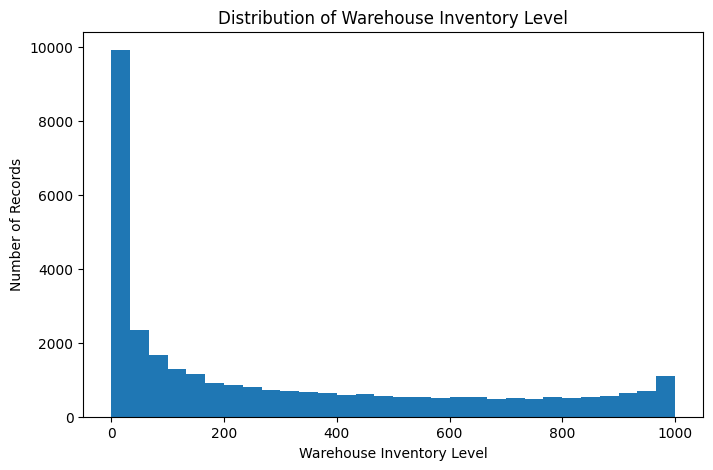

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(df["warehouse_inventory_level"], bins=30)

plt.title("Distribution of Warehouse Inventory Level")
plt.xlabel("Warehouse Inventory Level")
plt.ylabel("Number of Records")

plt.show()

Visualization 2: Historical Demand

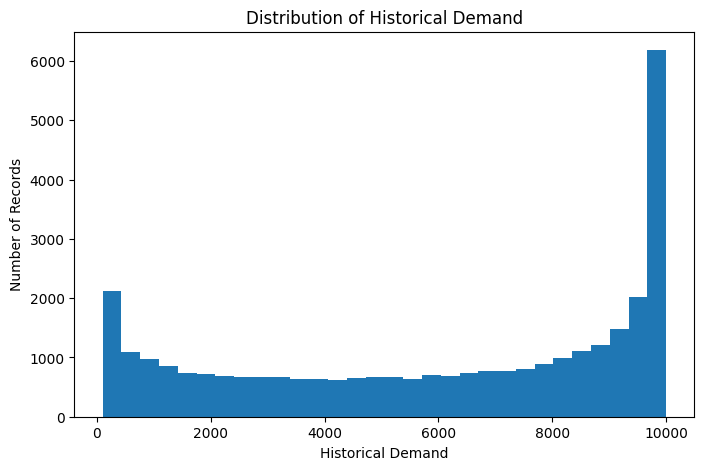

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(df["historical_demand"], bins=30)

plt.title("Distribution of Historical Demand")
plt.xlabel("Historical Demand")
plt.ylabel("Number of Records")

plt.show()

Visualization 3: Shipping Costs

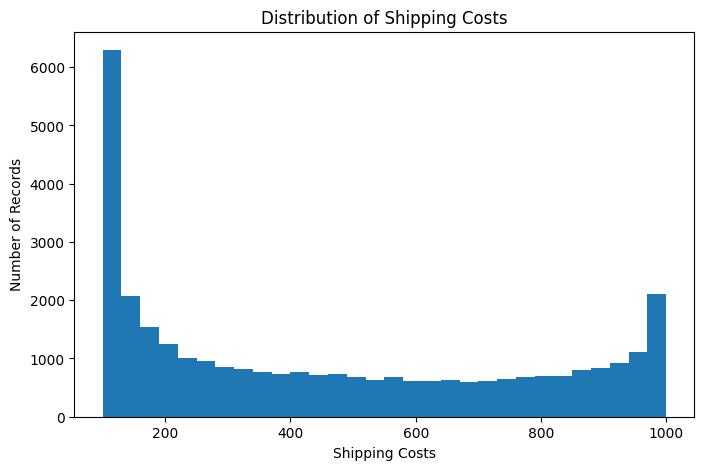

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(df["shipping_costs"], bins=30)

plt.title("Distribution of Shipping Costs")
plt.xlabel("Shipping Costs")
plt.ylabel("Number of Records")

plt.show()

Visualization 4: Risk Classification

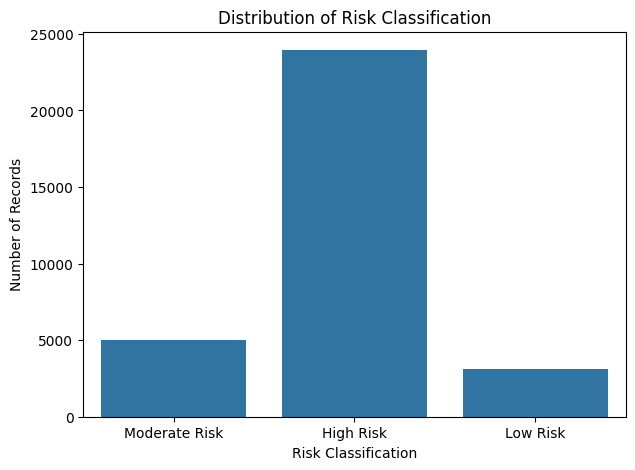

In [18]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="risk_classification"
)

plt.title("Distribution of Risk Classification")
plt.xlabel("Risk Classification")
plt.ylabel("Number of Records")

plt.show()

Visualization 5: Inventory vs Demand

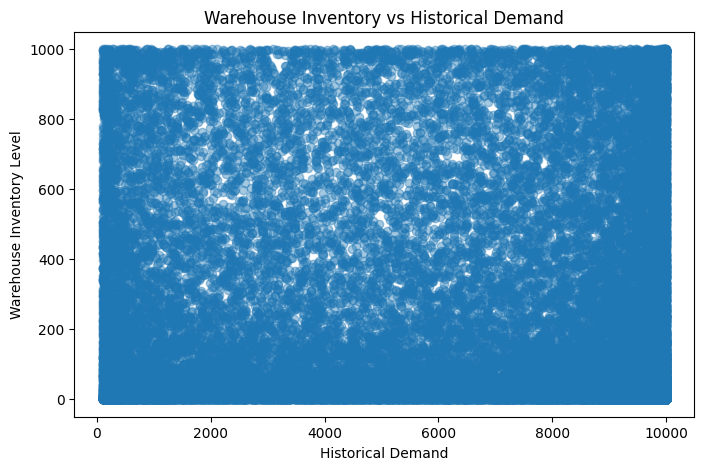

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["historical_demand"],
    df["warehouse_inventory_level"],
    alpha=0.4
)

plt.title("Warehouse Inventory vs Historical Demand")
plt.xlabel("Historical Demand")
plt.ylabel("Warehouse Inventory Level")

plt.show()

Visualization 6: Shipping Cost vs Lead Time

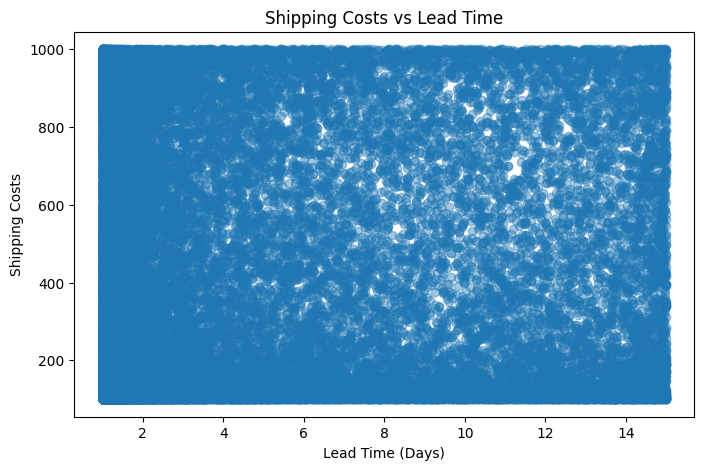

In [15]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["lead_time_days"],
    df["shipping_costs"],
    alpha=0.4
)

plt.title("Shipping Costs vs Lead Time")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Shipping Costs")

plt.show()

Visualization 7: Correlation Heatmap

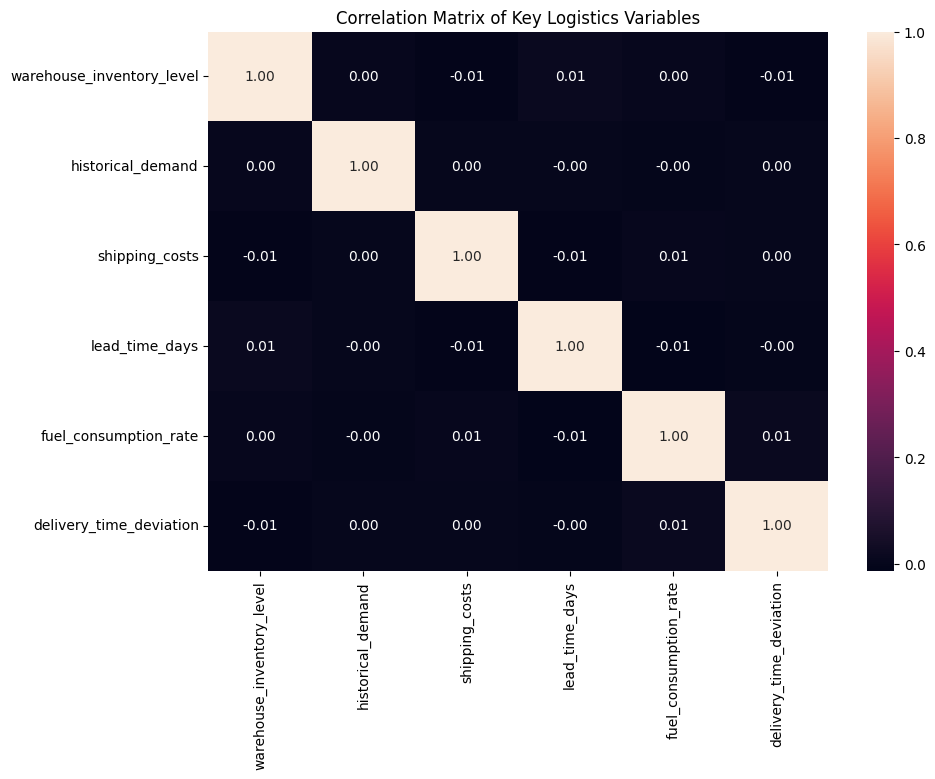

In [17]:
correlation_matrix = df[key_variables].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix of Key Logistics Variables")

plt.show()

Find the strongest relationships

In [19]:
corr = df[key_variables].corr()

corr_pairs = corr.unstack()

corr_pairs = corr_pairs[
    corr_pairs.index.get_level_values(0) !=
    corr_pairs.index.get_level_values(1)
]

corr_pairs.abs().sort_values(ascending=False).head(10)

,,0
fuel_consumption_rate,lead_time_days,0.012604
lead_time_days,fuel_consumption_rate,0.012604
delivery_time_deviation,fuel_consumption_rate,0.012495
fuel_consumption_rate,delivery_time_deviation,0.012495
warehouse_inventory_level,lead_time_days,0.011781
lead_time_days,warehouse_inventory_level,0.011781
delivery_time_deviation,warehouse_inventory_level,0.007463
warehouse_inventory_level,delivery_time_deviation,0.007463
shipping_costs,lead_time_days,0.007044
lead_time_days,shipping_costs,0.007044


Analyze average metrics by risk

In [20]:
risk_analysis = df.groupby("risk_classification")[
    [
        "warehouse_inventory_level",
        "historical_demand",
        "shipping_costs",
        "lead_time_days",
        "delivery_time_deviation",
        "delay_probability"
    ]
].mean()

risk_analysis

,warehouse_inventory_level,historical_demand,shipping_costs,lead_time_days,delivery_time_deviation,delay_probability
risk_classification,,,,,,
High Risk,297.787318,6020.723276,458.640398,5.241082,5.184047,0.698595
Low Risk,311.681844,6007.759661,463.119175,5.296713,5.118329,0.706961
Moderate Risk,298.553763,6036.946828,460.557869,5.119661,5.183886,0.696487


compare delay probability by risk classification.

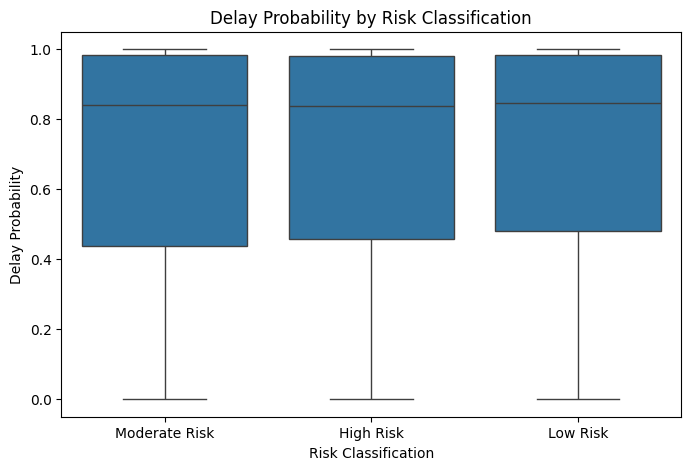

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="risk_classification",
    y="delay_probability"
)

plt.title("Delay Probability by Risk Classification")
plt.xlabel("Risk Classification")
plt.ylabel("Delay Probability")

plt.show()